In [130]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import yfinance as yf
import statsmodels.api as sm

In [131]:
folderPath = os.path.join(os.getcwd(), 'csse_covid_19_daily_reports_us')
files = []
for f in os.listdir(folderPath):
    if '2021' in f:
        files.append(f)

df_list = []
for file in files:
    df_path = os.path.join(folderPath, file)
    df = pd.read_csv(df_path)
    df_list.append(df)

df_2021 = pd.concat(df_list, ignore_index=True)
display(df_2021)

,Province_State,Country_Region,Last_Update,Lat,Long_,Confirmed,Deaths,Recovered,Active,FIPS,...,Total_Test_Results,People_Hospitalized,Case_Fatality_Ratio,UID,ISO3,Testing_Rate,Hospitalization_Rate,Date,People_Tested,Mortality_Rate
0,Alabama,US,2021-07-05 04:31:17,32.3182,-86.9023,551298,11358,NaN,NaN,1.0,...,NaN,NaN,2.060229,84000001.0,USA,NaN,NaN,2021-07-04,NaN,NaN
1,Alaska,US,2021-07-05 04:31:17,61.3707,-152.4044,71384,377,NaN,NaN,2.0,...,2382952.0,NaN,0.528130,84000002.0,USA,325742.367182,NaN,2021-07-04,NaN,NaN
2,American Samoa,US,2021-07-05 04:31:17,-14.2710,-170.1320,0,0,NaN,NaN,60.0,...,2140.0,NaN,NaN,16.0,ASM,3846.084722,NaN,2021-07-04,NaN,NaN
3,Arizona,US,2021-07-05 04:31:17,33.7298,-111.4312,896960,17979,NaN,NaN,4.0,...,10294689.0,NaN,2.004437,84000004.0,USA,141435.489249,NaN,2021-07-04,NaN,NaN
4,Arkansas,US,2021-07-05 04:31:17,34.9697,-92.3731,350579,5913,NaN,NaN,5.0,...,3135625.0,NaN,1.686638,84000005.0,USA,103904.196561,NaN,2021-07-04,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21165,Virginia,US,2021-06-15 04:31:17,37.7693,-78.1700,677812,11318,NaN,NaN,51.0,...,7553224.0,NaN,1.669785,84000051.0,USA,88491.678128,NaN,2021-06-14,NaN,NaN
21166,Washington,US,2021-06-15 04:31:17,47.4009,-121.4905,444722,5782,NaN,NaN,53.0,...,7358062.0,NaN,1.300138,84000053.0,USA,96627.253988,NaN,2021-06-14,NaN,NaN
21167,West Virginia,US,2021-06-15 04:31:17,38.4912,-80.9545,163144,2853,NaN,NaN,54.0,...,2972502.0,NaN,1.748762,84000054.0,USA,165862.621760,NaN,2021-06-14,NaN,NaN
21168,Wisconsin,US,2021-06-15 04:31:17,44.2685,-89.6165,676276,8015,NaN,NaN,55.0,...,8893572.0,NaN,1.185167,84000055.0,USA,0.000015,NaN,2021-06-14,NaN,NaN


In [132]:
df_2021.columns

Index(['Province_State', 'Country_Region', 'Last_Update', 'Lat', 'Long_',
       'Confirmed', 'Deaths', 'Recovered', 'Active', 'FIPS', 'Incident_Rate',
       'Total_Test_Results', 'People_Hospitalized', 'Case_Fatality_Ratio',
       'UID', 'ISO3', 'Testing_Rate', 'Hospitalization_Rate', 'Date',
       'People_Tested', 'Mortality_Rate'],
      dtype='object')

In [133]:
df_2021.isna().sum()

Province_State              0
Country_Region              0
Last_Update                 0
Lat                       730
Long_                     730
Confirmed                   0
Deaths                      0
Recovered               18354
Active                  18354
FIPS                        0
Incident_Rate             730
Total_Test_Results       1112
People_Hospitalized     21170
Case_Fatality_Ratio       278
UID                         0
ISO3                        0
Testing_Rate             1112
Hospitalization_Rate    21170
Date                        0
People_Tested           21170
Mortality_Rate          21170
dtype: int64

In [134]:
len(df_2021['Date'].unique())

365

In [135]:
df_2021 = df_2021[['Date', 'Province_State', 'Confirmed', 'Deaths']].copy()
display(df_2021)

,Date,Province_State,Confirmed,Deaths
0,2021-07-04,Alabama,551298,11358
1,2021-07-04,Alaska,71384,377
2,2021-07-04,American Samoa,0,0
3,2021-07-04,Arizona,896960,17979
4,2021-07-04,Arkansas,350579,5913
...,...,...,...,...
21165,2021-06-14,Virginia,677812,11318
21166,2021-06-14,Washington,444722,5782
21167,2021-06-14,West Virginia,163144,2853
21168,2021-06-14,Wisconsin,676276,8015


In [136]:
df_2021['Date'] = pd.to_datetime(df_2021['Date'])
df_2021 = df_2021.sort_values(['Province_State', 'Date'])

df_2021['New_Confirmed'] = df_2021.groupby('Province_State')['Confirmed'].diff()
df_2021['New_Deaths'] = df_2021.groupby('Province_State')['Deaths'].diff()

In [137]:
display(df_2021.sort_values(['Date', 'Province_State']))
df_2021_US = df_2021.groupby('Date')[['New_Confirmed', 'New_Deaths']].sum().reset_index()
display(df_2021_US)

,Date,Province_State,Confirmed,Deaths,New_Confirmed,New_Deaths
12992,2021-01-01,Alabama,365747,4872,NaN,NaN
12993,2021-01-01,Alaska,47019,206,NaN,NaN
12994,2021-01-01,American Samoa,0,0,NaN,NaN
12995,2021-01-01,Arizona,530267,9015,NaN,NaN
12996,2021-01-01,Arkansas,229442,3711,NaN,NaN
...,...,...,...,...,...,...
169,2021-12-31,Virginia,1118518,15587,17618.0,22.0
170,2021-12-31,Washington,849075,9853,0.0,0.0
171,2021-12-31,West Virginia,328162,5336,0.0,0.0
172,2021-12-31,Wisconsin,1120663,11173,8008.0,22.0


,Date,New_Confirmed,New_Deaths
0,2021-01-01,0.0,0.0
1,2021-01-02,272624.0,2592.0
2,2021-01-03,203213.0,1401.0
3,2021-01-04,186732.0,2016.0
4,2021-01-05,232141.0,3576.0
...,...,...,...
360,2021-12-27,506072.0,1846.0
361,2021-12-28,372461.0,2281.0
362,2021-12-29,511022.0,2355.0
363,2021-12-30,597951.0,1487.0


In [138]:


# tickers = ["CVS", "JNJ", "ABBV"]

# processed_data = {}

# for ticker in tickers:
#     raw_df = yf.download(ticker, start="2021-01-01", end="2022-01-01")
    
#     df_daily = raw_df.resample('D').asfreq()
#     df_daily['Close'] = df_daily['Close'].ffill()
#     df_daily['Volume'] = df_daily['Volume'].fillna(0)
    
#     df_final = df_daily[['Close', 'Volume']].copy()
#     df_final.reset_index(inplace=True)
#     df_final['Date'] = df_final['Date'].dt.strftime('%Y-%m-%d')
    
#     processed_data[ticker] = df_final

# # --- Assign to specific, properly named variables ---
# df_CVS  = processed_data["CVS"]
# df_JNJ  = processed_data["JNJ"]
# df_ABBV = processed_data["ABBV"]


In [139]:
# df_2021_US['Date'] = df_2021_US['Date'].astype(str)


# def prepare_df(df, ticker):
#     temp = df.copy()
#     temp.columns = ['Date', f'{ticker}_Close', f'{ticker}_Volume']
#     temp['Date'] = temp['Date'].astype(str) 
#     return temp

# df_CVS_flat  = prepare_df(df_CVS, "CVS")
# df_JNJ_flat  = prepare_df(df_JNJ, "JNJ")
# df_ABBV_flat = prepare_df(df_ABBV, "ABBV")

# df_combined = pd.merge(df_2021_US, df_CVS_flat, on='Date', how='left')
# df_combined = pd.merge(df_combined, df_JNJ_flat, on='Date', how='left')
# df_combined = pd.merge(df_combined, df_ABBV_flat, on='Date', how='left')


display(df_combined)

,Date,New_Confirmed,New_Deaths,CVS_Close,CVS_Volume,JNJ_Close,JNJ_Volume,ABBV_Close,ABBV_Volume,Infection_Z,Mortality_Z,Infection_Momentum,Mortality_Momentum,Severity_Index,CVS_Return,JNJ_Return,ABBV_Return
0,2021-01-04,662569.0,6009.0,58.523392,11367200,135.059662,11765900,85.339401,9523400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-05,232141.0,3576.0,58.916393,8012200,136.647568,9602300,86.221870,6823800,NaN,NaN,NaN,NaN,NaN,0.006715,0.011757,0.010341
2,2021-01-06,259695.0,3870.0,60.672344,10142400,137.933456,8230100,85.477043,11017500,NaN,NaN,NaN,NaN,NaN,0.029804,0.009410,-0.008638
3,2021-01-07,285086.0,3993.0,61.868073,7962300,138.399475,7747200,86.391876,8196000,NaN,NaN,NaN,NaN,NaN,0.019708,0.003379,0.010703
4,2021-01-08,302860.0,4228.0,62.595535,11254700,138.114670,8228900,86.845261,5345900,NaN,NaN,NaN,NaN,NaN,0.011758,-0.002058,0.005248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,2021-12-27,1026177.0,3151.0,87.794556,2596600,150.115540,3704800,114.037132,4436800,2.586197,0.249151,1.259241,0.109743,0.950265,0.010759,0.008440,0.009918
248,2021-12-28,372461.0,2281.0,88.111794,2732400,150.717209,3187000,114.020157,4237200,2.963611,0.297176,1.403970,0.130744,1.097106,0.003613,0.004008,-0.000149
249,2021-12-29,511022.0,2355.0,88.909149,2782500,151.778900,3662000,114.843124,5594300,3.485658,0.330399,1.587556,0.143782,1.276977,0.009049,0.007044,0.007218
250,2021-12-30,597951.0,1487.0,88.891991,2484500,152.451294,4231800,115.326714,6354300,3.787544,0.326465,1.200740,0.132254,1.364789,-0.000193,0.004430,0.004211


In [140]:
tickers = ["CVS", "JNJ", "ABBV"]
stock_dfs = {}
for ticker in tickers:
    raw = yf.download(ticker, start="2021-01-01", end="2022-01-01")
    raw = raw[['Close', 'Volume']].copy()
    raw.columns = [f'{ticker}_Close', f'{ticker}_Volume']
    raw.reset_index(inplace=True)
    raw['Date'] = raw['Date'].dt.strftime('%Y-%m-%d')
    stock_dfs[ticker] = raw

# Combine COVID data with stock data
df_2021_US['Date'] = pd.to_datetime(df_2021_US['Date'])
trading_dates = pd.to_datetime(stock_dfs['CVS']['Date']).sort_values().tolist()

# Assign each COVID date to the next trading day
def assign_trading_day(d, trading_dates):
    for td in trading_dates:
        if td >= d:
            return td
    return pd.NaT

df_2021_US['Trading_Day'] = df_2021_US['Date'].apply(lambda d: assign_trading_day(d, trading_dates))
covid_by_trading_day = (df_2021_US.groupby('Trading_Day')[['New_Confirmed', 'New_Deaths']]
                                    .sum()
                                    .reset_index()
                                    .rename(columns={'Trading_Day': 'Date'}))
covid_by_trading_day['Date'] = covid_by_trading_day['Date'].dt.strftime('%Y-%m-%d')

# merge with stock data
df_combined = covid_by_trading_day.merge(stock_dfs['CVS'], on='Date', how='inner') \
                                   .merge(stock_dfs['JNJ'], on='Date', how='inner') \
                                   .merge(stock_dfs['ABBV'], on='Date', how='inner')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [141]:
# ensuring that there are no negative values in the 'New_Confirmed' and 'New_Deaths' columns
print("negatives - New_Confirmed:", (df_combined['New_Confirmed'] < 0).sum())
print("negatives - New_Deaths:", (df_combined['New_Deaths'] < 0).sum())

df_combined['New_Confirmed'] = df_combined['New_Confirmed'].clip(lower=0)
df_combined['New_Deaths'] = df_combined['New_Deaths'].clip(lower=0)

print("post-processing negatives - New_Confirmed:", (df_combined['New_Confirmed'] < 0).sum())
print("post-processing negatives - New_Deaths:", (df_combined['New_Deaths'] < 0).sum())
display(df_combined)

negatives - New_Confirmed: 0
negatives - New_Deaths: 0
post-processing negatives - New_Confirmed: 0
post-processing negatives - New_Deaths: 0


,Date,New_Confirmed,New_Deaths,CVS_Close,CVS_Volume,JNJ_Close,JNJ_Volume,ABBV_Close,ABBV_Volume
0,2021-01-04,662569.0,6009.0,58.523392,11367200,135.059662,11765900,85.339401,9523400
1,2021-01-05,232141.0,3576.0,58.916393,8012200,136.647568,9602300,86.221870,6823800
2,2021-01-06,259695.0,3870.0,60.672344,10142400,137.933456,8230100,85.477043,11017500
3,2021-01-07,285086.0,3993.0,61.868073,7962300,138.399475,7747200,86.391876,8196000
4,2021-01-08,302860.0,4228.0,62.595535,11254700,138.114670,8228900,86.845261,5345900
...,...,...,...,...,...,...,...,...,...
247,2021-12-27,1026177.0,3151.0,87.794556,2596600,150.115540,3704800,114.037132,4436800
248,2021-12-28,372461.0,2281.0,88.111794,2732400,150.717209,3187000,114.020157,4237200
249,2021-12-29,511022.0,2355.0,88.909149,2782500,151.778900,3662000,114.843124,5594300
250,2021-12-30,597951.0,1487.0,88.891991,2484500,152.451294,4231800,115.326714,6354300


In [142]:
# # Drop rows where any market price (Close) is NaN or 0 - because there is no price during holidays
# price_cols = ['CVS_Close', 'JNJ_Close', 'ABBV_Close']
# df_combined = df_combined[~(df_combined[price_cols].isna().any(axis=1) | (df_combined[price_cols] == 0).any(axis=1))]

# print(f"remaining rows: {len(df_combined)}")
# display(df_combined)

In [143]:
# calculate the rolling averages to reduce noise in data
inf_rolling = df_combined['New_Confirmed'].rolling(window=7).mean()
mor_rolling = df_combined['New_Deaths'].rolling(window=14).mean()

In [144]:
# calculate Z-scores for infection and mortality rates
df_combined['Infection_Z'] = (inf_rolling - inf_rolling.mean()) / inf_rolling.std()
df_combined['Mortality_Z'] = (mor_rolling - mor_rolling.mean()) / mor_rolling.std()

In [145]:
# calculat the momentum (change rate) of infection and mortality
df_combined['Infection_Momentum'] = inf_rolling.pct_change(7)
df_combined['Mortality_Momentum'] = mor_rolling.pct_change(14)

In [146]:
# calculate a composite severity index (weighted average of infection and mortality Z-scores)
df_combined['Severity_Index'] = 0.3 * df_combined['Infection_Z'] + 0.7 * df_combined['Mortality_Z']

In [147]:
# calculate the daily change rates (returns) for stock prices
df_combined['CVS_Return'] = df_combined['CVS_Close'].pct_change() 
df_combined['JNJ_Return'] = df_combined['JNJ_Close'].pct_change() 
df_combined['ABBV_Return'] = df_combined['ABBV_Close'].pct_change()

In [148]:
features = ['Severity_Index', 'Infection_Momentum', 'Mortality_Momentum']

for stock in ['CVS_Return', 'JNJ_Return', 'ABBV_Return']:
    reg_df = df_combined[features + [stock]].dropna()
    X = sm.add_constant(reg_df[features])
    y = reg_df[stock]
    model = sm.OLS(y, X).fit()
    print(f"\n=== {stock} ===")
    print(model.summary())


=== CVS_Return ===
                            OLS Regression Results                            
Dep. Variable:             CVS_Return   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.013
Method:                 Least Squares   F-statistic:                   0.02798
Date:                Sun, 03 May 2026   Prob (F-statistic):              0.994
Time:                        18:41:52   Log-Likelihood:                 654.00
No. Observations:                 225   AIC:                            -1300.
Df Residuals:                     221   BIC:                            -1286.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const           

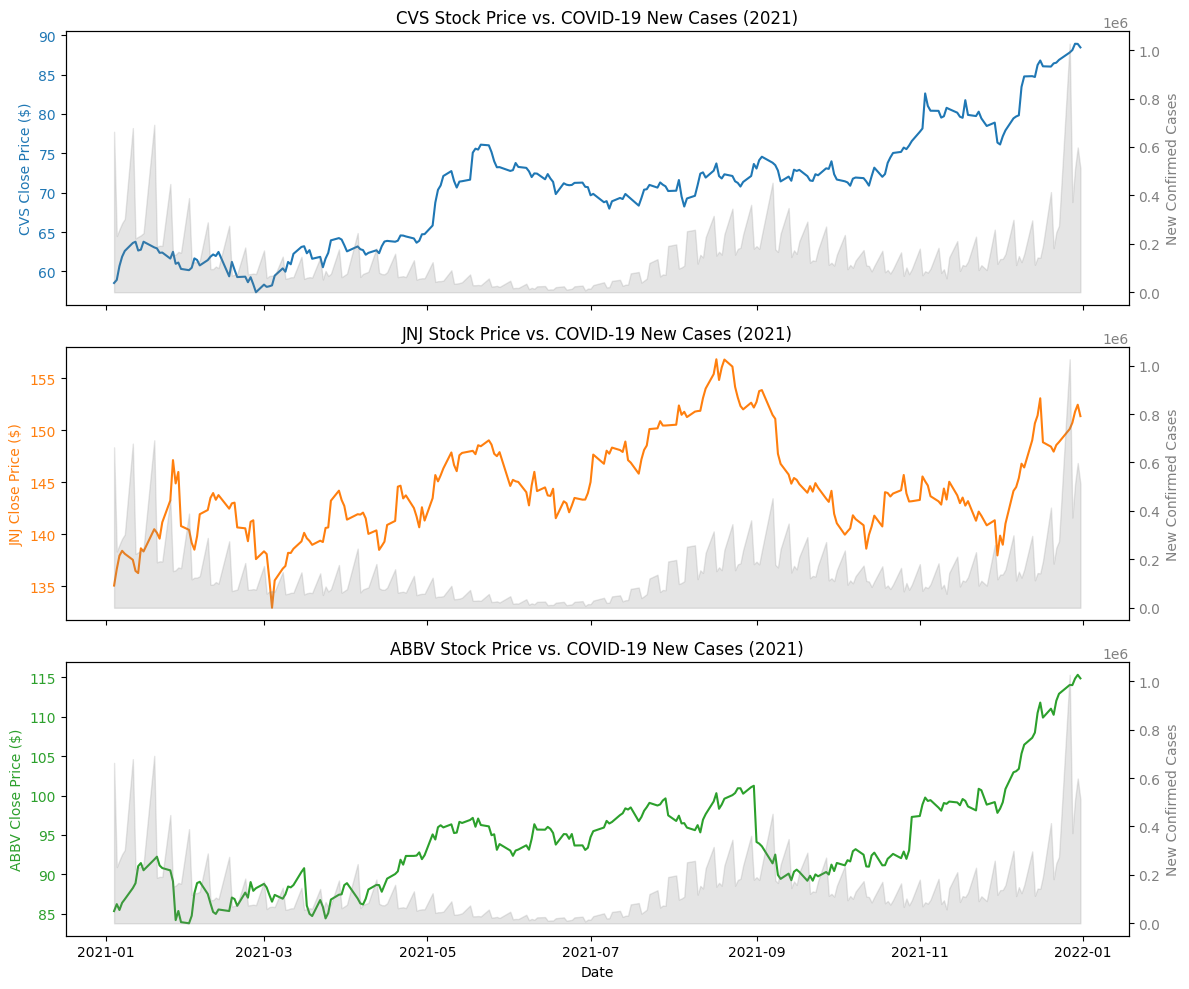

In [149]:


df_combined['Date'] = pd.to_datetime(df_combined['Date'])
tickers = ['CVS', 'JNJ', 'ABBV']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for ax, ticker, color in zip(axes, tickers, colors):
    ax.plot(df_combined['Date'], df_combined[f'{ticker}_Close'], 
            color=color, label=f'{ticker} Close')
    ax.set_ylabel(f'{ticker} Close Price ($)', color=color)
    ax.tick_params(axis='y', labelcolor=color)
    ax.set_title(f'{ticker} Stock Price vs. COVID-19 New Cases (2021)')
    
    ax2 = ax.twinx()
    ax2.fill_between(df_combined['Date'], df_combined['New_Confirmed'], 
                     color='gray', alpha=0.2, label='New Confirmed')
    ax2.set_ylabel('New Confirmed Cases', color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()